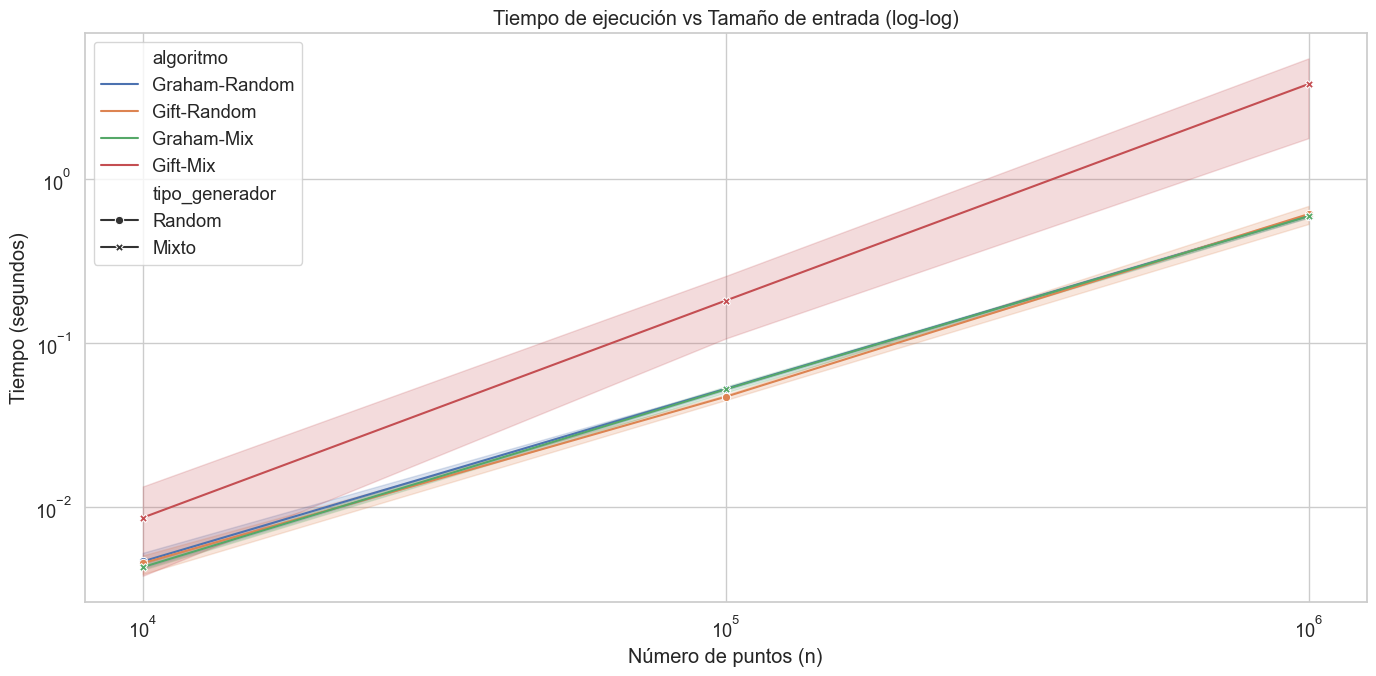

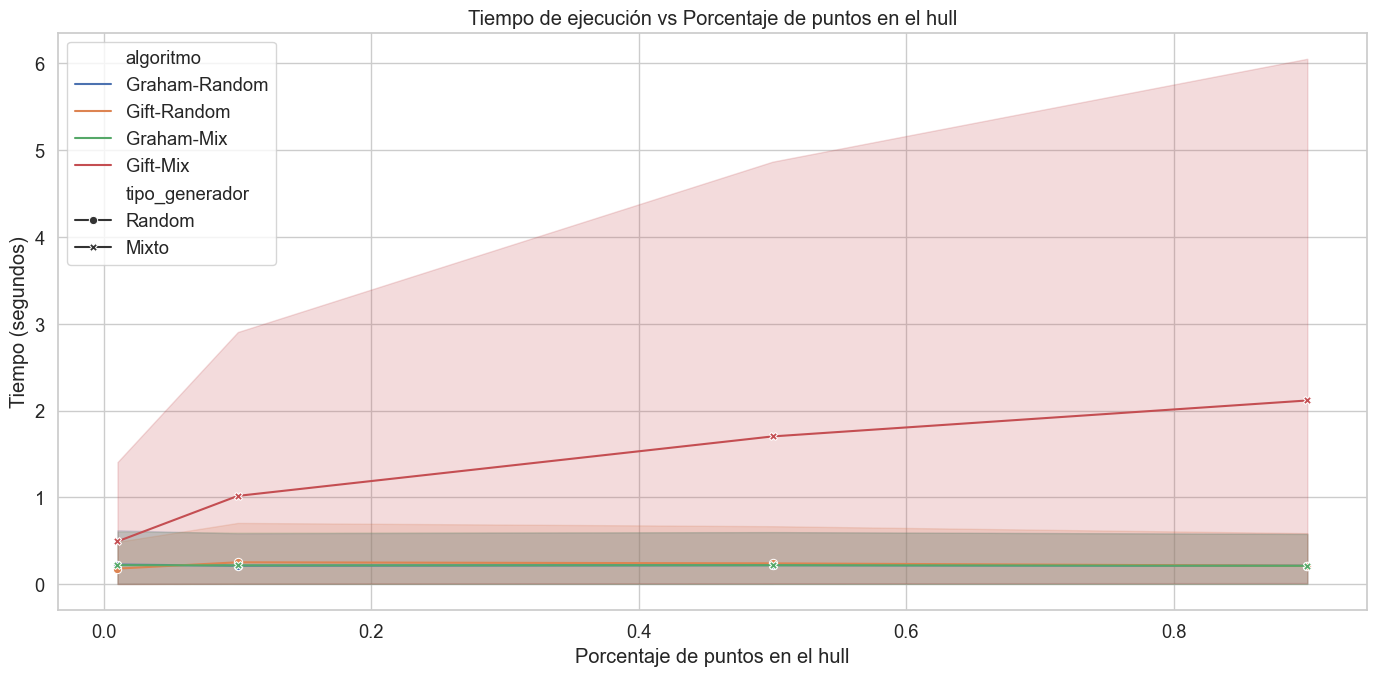

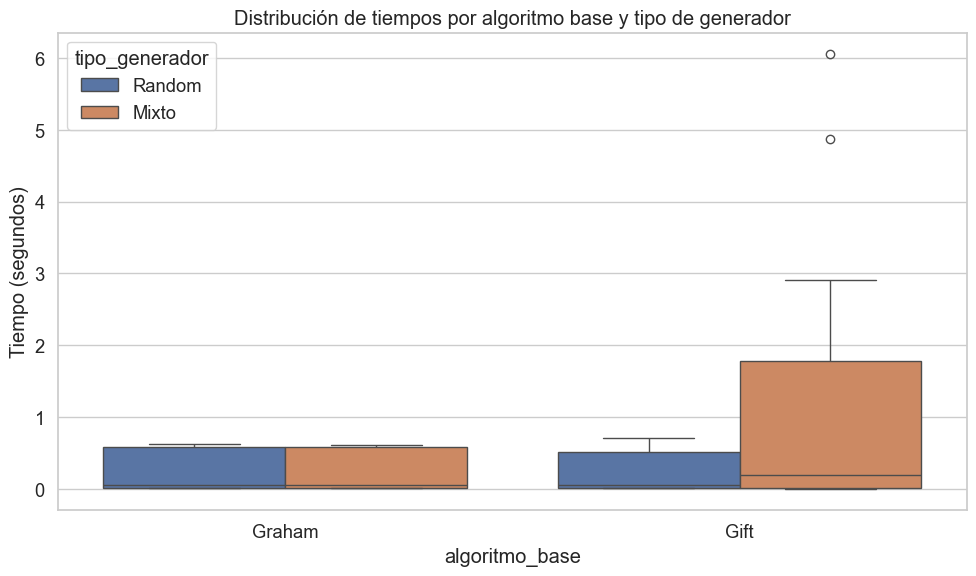

,algoritmo,porcentaje,n,tiempo_promedio
0,Gift-Mix,0.01,10000,0.002986
1,Gift-Mix,0.01,100000,0.071739
2,Gift-Mix,0.01,1000000,1.406620
3,Gift-Mix,0.10,10000,0.006283
4,Gift-Mix,0.10,100000,0.141893
5,Gift-Mix,0.10,1000000,2.905290
6,Gift-Mix,0.50,10000,0.011149
7,Gift-Mix,0.50,100000,0.230062
8,Gift-Mix,0.50,1000000,4.867810
9,Gift-Mix,0.90,10000,0.014099


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar CSV
df = pd.read_csv("resultados.csv")

# Asegurar tipos correctos
df["n"] = pd.to_numeric(df["n"], errors="coerce")
df["porcentaje"] = df["porcentaje"].astype(float)
df["tiempo"] = df["tiempo"].astype(float)
df["algoritmo"] = df["algoritmo"].astype(str)
# df["tipo_generador"] = df["tipo_generador"].astype(str)

# Estilo bonito
sns.set(style="whitegrid", font_scale=1.2)

# Columnas auxiliares
df["algoritmo_base"] = df["algoritmo"].apply(lambda x: x.split("-")[0])
df["configuracion"] = df["tipo_generador"] + " (" + df["porcentaje"].astype(str) + ")"

# --- Gráfico 1: Tiempo vs n (log-log) ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x="n", y="tiempo", hue="algoritmo", style="tipo_generador", markers=True, dashes=False)
plt.xscale("log")
plt.yscale("log")
plt.title("Tiempo de ejecución vs Tamaño de entrada (log-log)")
plt.xlabel("Número de puntos (n)")
plt.ylabel("Tiempo (segundos)")
plt.tight_layout()
plt.show()

# --- Gráfico 2: Tiempo vs porcentaje ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x="porcentaje", y="tiempo", hue="algoritmo", style="tipo_generador", markers=True, dashes=False)
plt.title("Tiempo de ejecución vs Porcentaje de puntos en el hull")
plt.xlabel("Porcentaje de puntos en el hull")
plt.ylabel("Tiempo (segundos)")
plt.tight_layout()
plt.show()

# --- Gráfico 3: Boxplot resumen ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="algoritmo_base", y="tiempo")
plt.title("Distribución de tiempos por algoritmo base y tipo de generador")
plt.ylabel("Tiempo (segundos)")
plt.tight_layout()
plt.show()

# --- Tabla resumen por configuración ---
resumen = df.groupby(["algoritmo", "porcentaje", "n"]).agg(
    tiempo_promedio=("tiempo", "mean")
).reset_index()

# Mostrar tabla
display(resumen)
